# Testing 21cmFast

## Initial testing

### Importing modules

In [1]:
import py21cmfast as p21c
from tempfile import mkdtemp
from pathlib import Path
from matplotlib import pyplot as plt
from astropy import units as u
from astropy.cosmology import z_at_value as getz
import numpy as np

print(f' Using 21cmFAST version {p21c.__version__}')

 Using 21cmFAST version 4.2


### Defining Simulation inputs

The list of template configurations we want to load as defaults include:
    The configuration from Park et al. 2019 (`Park19`)
    A box with preset size and resolution

In [2]:
"""Differences between Park19 Model and this one:

HII_DIM=512
LOWRES_CELL_SIZE_MPC=2
PERTURB_ON_HIGH_RES = True

From Meiksin 2021 and Reis et al. 2021:
- USE_CMB_HEATING = True
- USE_LYA_HEATING = True

From Qin et al. 2024 (Table 1):

- F_STAR10 = -1.42
- ALPHA_STAR = 0.51
- F_ESC10 = -1.08
- ALPHA_ESC = -0.46
- t_STAR = 0.34
- M_TURN = 8.46

This assumes a constant f_esc. Pursuing a non-constant f_esc will be optional later on.
"""

# Define inputs
scin_inputs = p21c.InputParameters.from_template(
    ["Park19", "large"],
    random_seed = 20250303,
    HII_DIM = 512,
    LOWRES_CELL_SIZE_MPC = 2,
    N_THREADS = 8,
    USE_CMB_HEATING = True,
    USE_LYA_HEATING = True,
    F_STAR10 = -1.42,
    ALPHA_STAR = 0.51,
    F_ESC10 = -1.08,
    ALPHA_ESC = -0.46,
    t_STAR = 0.34,
    M_TURN = 8.46
)

test_inputs = p21c.InputParameters.from_template(
    ["Park19", "large"],
    random_seed = 20250303,
    HII_DIM = 128,
    LOWRES_CELL_SIZE_MPC = 2,
    N_THREADS = 8,
    USE_CMB_HEATING = True,
    USE_LYA_HEATING = True,
    F_STAR10 = -1.42,
    ALPHA_STAR = 0.51,
    F_ESC10 = -1.08,
    ALPHA_ESC = -0.46,
    t_STAR = 0.34,
    M_TURN = 8.46
)

test_toml_file = "test-park19.toml"
scin_toml_file = "scin-park19.toml"

p21c.write_template(test_inputs, test_toml_file)
p21c.write_template(scin_inputs, scin_toml_file)

## Running the test lightcone file

In [3]:
# Creating an array of Mpc values similar to how 21cmFast does it
cosmo = test_inputs.cosmo_params.cosmo
z_ref = 5.5
d_t = 1024
step = 2 * u.Mpc

start = cosmo.comoving_distance(z_ref).to_value(u.Mpc)
inc = step.to_value(u.Mpc)
total = d_t * inc
end = start + total - inc

print(start, inc, total, end)

print("End redshift z =", getz(cosmo.comoving_distance, end * u.Mpc))

def generate(start = 0, step = 1, num = 1):
    """Create an array of linearly-increasing consecutive entries with a defined start, step size, and step count. Similar to np.linspace and np.arrange."""
    return start + np.arange(0, num) * step

lc_dist = generate(start=start, step=inc, num=d_t) * u.Mpc

print(lc_dist, lc_dist.shape)

8199.586305872284 2.0 2048.0 10245.586305872284
End redshift z = 13.447017966382665 redshift
[ 8199.58630587  8201.58630587  8203.58630587 ... 10241.58630587
 10243.58630587 10245.58630587] Mpc (1024,)


In [5]:
cache = p21c.OutputCache(mkdtemp())

lcn = p21c.RectilinearLightconer.between_redshifts(
    min_redshift=5.5,
    max_redshift=13.5,
    quantities=("brightness_temp", "density"),
    resolution=step,
    
)

lcn_abd = p21c.RectilinearLightconer(
    lc_distances=lc_dist,
    quantities=("brightness_temp", "density")
    )

In [10]:
lightcone = p21c.run_lightcone(
    lightconer=lcn_abd,
    inputs=test_inputs,
    cache=cache,
    progressbar=True
)

Output()

Output()

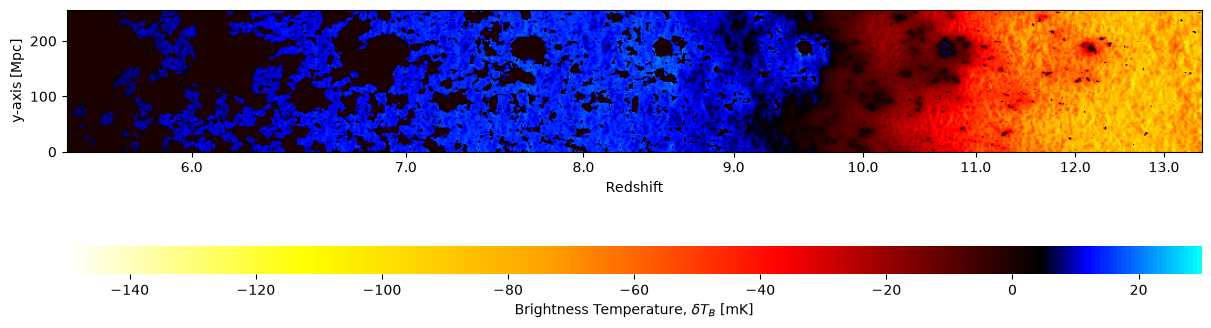

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
p21c.plotting.lightcone_sliceplot(lightcone, ax=ax, fig=fig);

In [12]:
print(lightcone.lightcones)

{'brightness_temp': array([[[  0.        ,   0.        ,   0.        , ..., -66.55055   ,
         -65.68962   , -66.766174  ],
        [  0.        ,   0.        ,   0.        , ..., -68.3224    ,
         -66.68068   , -64.18963   ],
        [  0.        ,   0.        ,   0.        , ..., -67.04041   ,
         -69.56841   , -72.11316   ],
        ...,
        [  0.        ,   0.        ,   0.        , ..., -37.377277  ,
          -1.5617584 , -80.92609   ],
        [  0.        ,   0.        ,   0.        , ..., -88.64842   ,
         -86.021515  , -71.37338   ],
        [  0.        ,   0.        ,   0.        , ..., -75.24881   ,
         -72.87447   , -71.66756   ]],

       [[  0.        ,   0.        ,   0.        , ..., -70.67125   ,
         -72.4076    , -69.62266   ],
        [  0.        ,   0.        ,   0.        , ..., -69.69207   ,
         -73.82046   , -72.84609   ],
        [  0.        ,   0.        ,   0.        , ..., -67.32228   ,
         -68.544075  , -70.8379

In [13]:
print(lightcone.lightcone_distances.shape)

(1024,)
